In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('svm_new_data_predictions_28.csv')

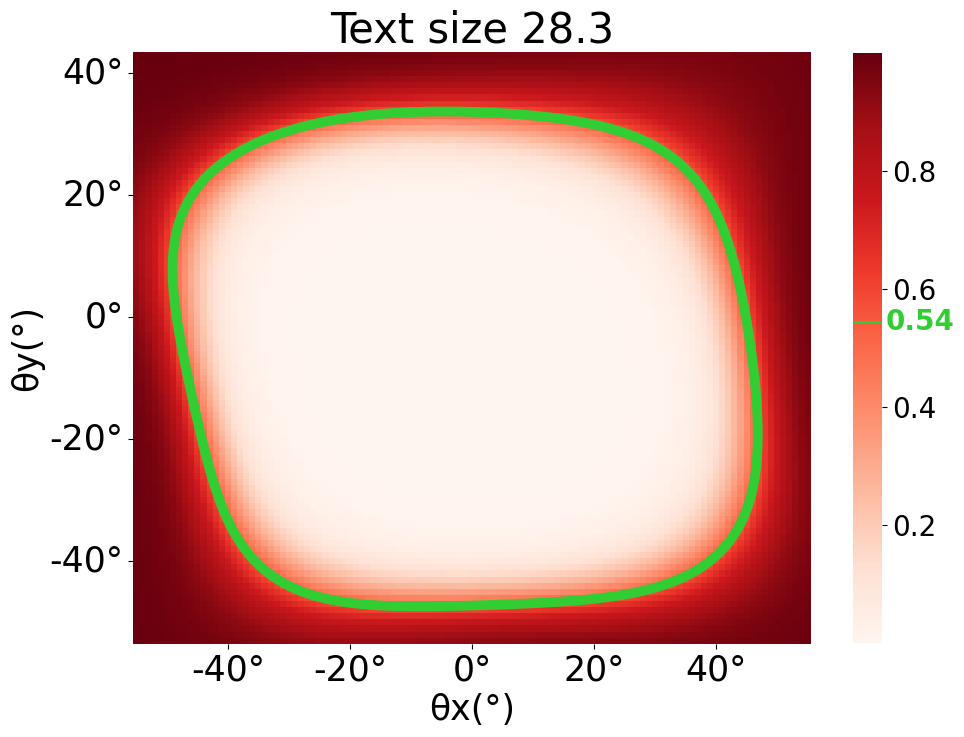

In [98]:
# 2. 히트맵을 위한 데이터 재구조화 (Pivot)
# Yaw(x_theta)를 가로축(Columns), Pitch(y_theta)를 세로축(Index)으로 '올바르게' 설정
heatmap_data = df.pivot(index='y_theta', columns='x_theta', values='Probability')

# 컨투어(등고선)를 그리기 위한 좌표값 준비
X = heatmap_data.columns.values # x_theta
Y = heatmap_data.index.values   # y_theta
Z = heatmap_data.values

# 3. 그래프 그리기 (단일 컬러 + 검정 등고선 버전)
plt.figure(figsize=(10, 8))

ax = sns.heatmap(heatmap_data, cmap='Reds', square=True, cbar_kws={"shrink": 0.82})

# 컬러바 및 임계값 설정
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)
threshold = 0.5433169615
cbar.ax.axhline(y=threshold, color='limegreen', linewidth=2)
cbar.ax.text(1.1, threshold, f'{threshold:.2f}', 
             color='limegreen', 
             va='center', 
             ha='left', 
             fontweight='bold',
             fontsize=20)

# 눈금 값을 자동으로 계산하는 함수 정의
def get_10_step_ticks(data_array):
    min_val = np.ceil(np.min(data_array) / 20) *20
    max_val = np.floor(np.max(data_array) / 20) * 20
    return np.arange(min_val, max_val + 20, 20)

yaw_tick_vals = get_10_step_ticks(heatmap_data.columns.values)
pitch_tick_vals = get_10_step_ticks(heatmap_data.index.values)

# 실제 히트맵 상의 위치(Index) 찾기 (+ 0.5는 셀 중앙 정렬용)
x_indices = [np.argmin(np.abs(heatmap_data.columns.values - val)) + 0.5 for val in yaw_tick_vals]
y_indices = [np.argmin(np.abs(heatmap_data.index.values - val)) + 0.5 for val in pitch_tick_vals]

# 그래프에 표시할 라벨 문자열 생성 (정수로 변환 후 '°' 붙임)
yaw_ticks_labels = [f"{int(val)}°" for val in yaw_tick_vals]
pitch_ticks_labels = [f"{int(val)}°" for val in pitch_tick_vals]

plt.xticks(x_indices, yaw_ticks_labels, fontsize=25, rotation=0)
plt.yticks(y_indices, pitch_ticks_labels, fontsize=25)

# 등고선(Contour) 추가
plt.contour(np.arange(len(X)) + 0.5, 
            np.arange(len(Y)) + 0.5, 
            Z, 
            levels=[threshold],
            colors='limegreen', 
            linewidths=7)

# 그래프 설정
plt.title('Text size 28.3', fontsize=30)
plt.xlabel('θx(°)', fontsize=25)
plt.ylabel('θy(°)', fontsize=25)

# 세로축 방향 뒤집기 (일반적인 Pitch 좌표계 대응)
plt.gca().invert_yaxis()

# 이미지 저장 및 출력
plt.tight_layout()
plt.savefig('my_probability_heatmap_fixed.png', dpi=300)
plt.show()